# Stroke Prediction Machine Learning System
## COM 763 - Advanced Machine Learning - Portfolio Task 1

## 1. Problem Definition and System Framing

### Problem Statement
Stroke is a leading cause of death and disability worldwide. Early prediction of stroke risk can enable preventive interventions and lifestyle modifications. This project develops a predictive model to identify individuals at high risk of stroke based on clinical and demographic features.

## 2. Data Pipeline and Feature Handling

### 2.1 Data Loading and Initial Exploration

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import pickle

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load dat
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print("Dataset Shape:", df.shape)

Dataset Shape: (5110, 12)


In [89]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [90]:
print("\nBasic Statistics:")
df.describe()


Basic Statistics:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### 2.2 Missing Values Analysis

Missing Values:
  Column  Missing_Count  Percentage
9    bmi            201    3.933464


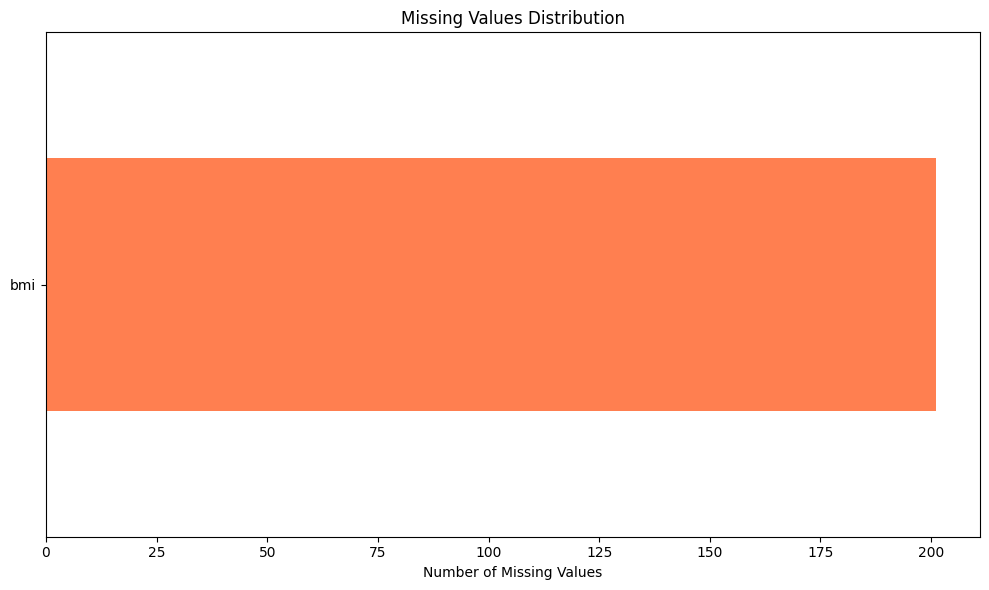

In [91]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
missing_data.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Values Distribution')
plt.tight_layout()
plt.show()


### 2.3 Target Variable Distribution (Class Imbalance Analysis)

Target Variable Distribution:
stroke
0    4861
1     249
Name: count, dtype: int64

Percentage:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


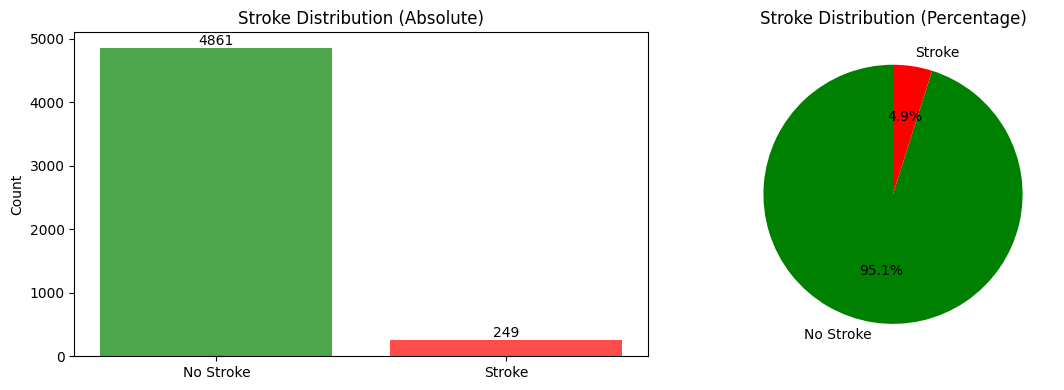


⚠️ Key Insight: Significant class imbalance detected. Will use appropriate evaluation metrics and techniques.
✓ Saved: 02_target_distribution.png


In [92]:
# Analyze class distribution
print("Target Variable Distribution:")
print(df['stroke'].value_counts())
print("\nPercentage:")
print(df['stroke'].value_counts(normalize=True) * 100)

# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
stroke_counts = df['stroke'].value_counts()
axes[0].bar(['No Stroke', 'Stroke'], stroke_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Stroke Distribution (Absolute)')
for i, v in enumerate(stroke_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

# Pie chart
axes[1].pie(stroke_counts.values, labels=['No Stroke', 'Stroke'], 
             autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Stroke Distribution (Percentage)')

plt.tight_layout()
plt.savefig('02_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n⚠️ Key Insight: Significant class imbalance detected. Will use appropriate evaluation metrics and techniques.")
print("✓ Saved: 02_target_distribution.png")

### 2.4 Exploratory Data Analysis

In [93]:
# Analyze categorical features
print("Categorical Features Analysis:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Categorical Features Analysis:

gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


### 2.5 Feature Engineering and Data Preprocessing

In [94]:
# Drop ID
df = df.drop('id', axis=1)


### 2.6 Feature Analysis and Visualization

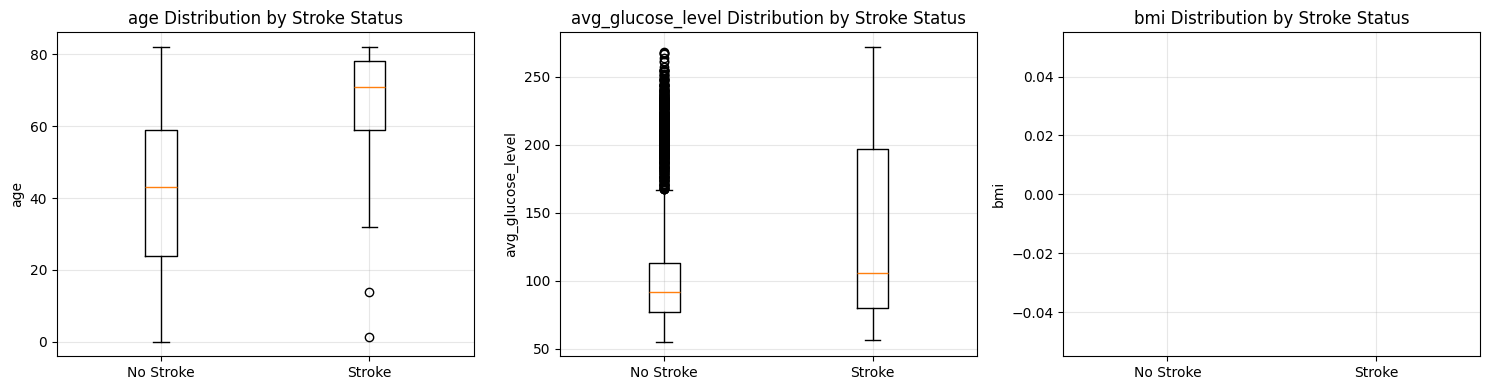

✓ Saved: 03_numerical_features_analysis.png


In [95]:
# Analyze relationship between numerical features and target
numerical_features = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(numerical_features):
    # Box plot by stroke status
    data_no_stroke = df[df['stroke'] == 0][feature]
    data_stroke = df[df['stroke'] == 1][feature]
    
    axes[idx].boxplot([data_no_stroke, data_stroke], labels=['No Stroke', 'Stroke'])
    axes[idx].set_ylabel(feature)
    axes[idx].set_title(f'{feature} Distribution by Stroke Status')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_numerical_features_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_numerical_features_analysis.png")

Correlation with Stroke Target:
stroke                     1.000000
age                        0.245257
heart_disease              0.134914
avg_glucose_level          0.131945
hypertension               0.127904
married_Yes                0.108340
smoking_formerly smoked    0.064556
work_Self-employed         0.062168
bmi                        0.036110
residence_Urban            0.015458
work_Private               0.011888
gender_Male                0.009117
smoking_smokes             0.008939
gender_Other              -0.003166
smoking_never smoked      -0.004129
work_Never_worked         -0.014882
work_children             -0.083869
Name: stroke, dtype: float64


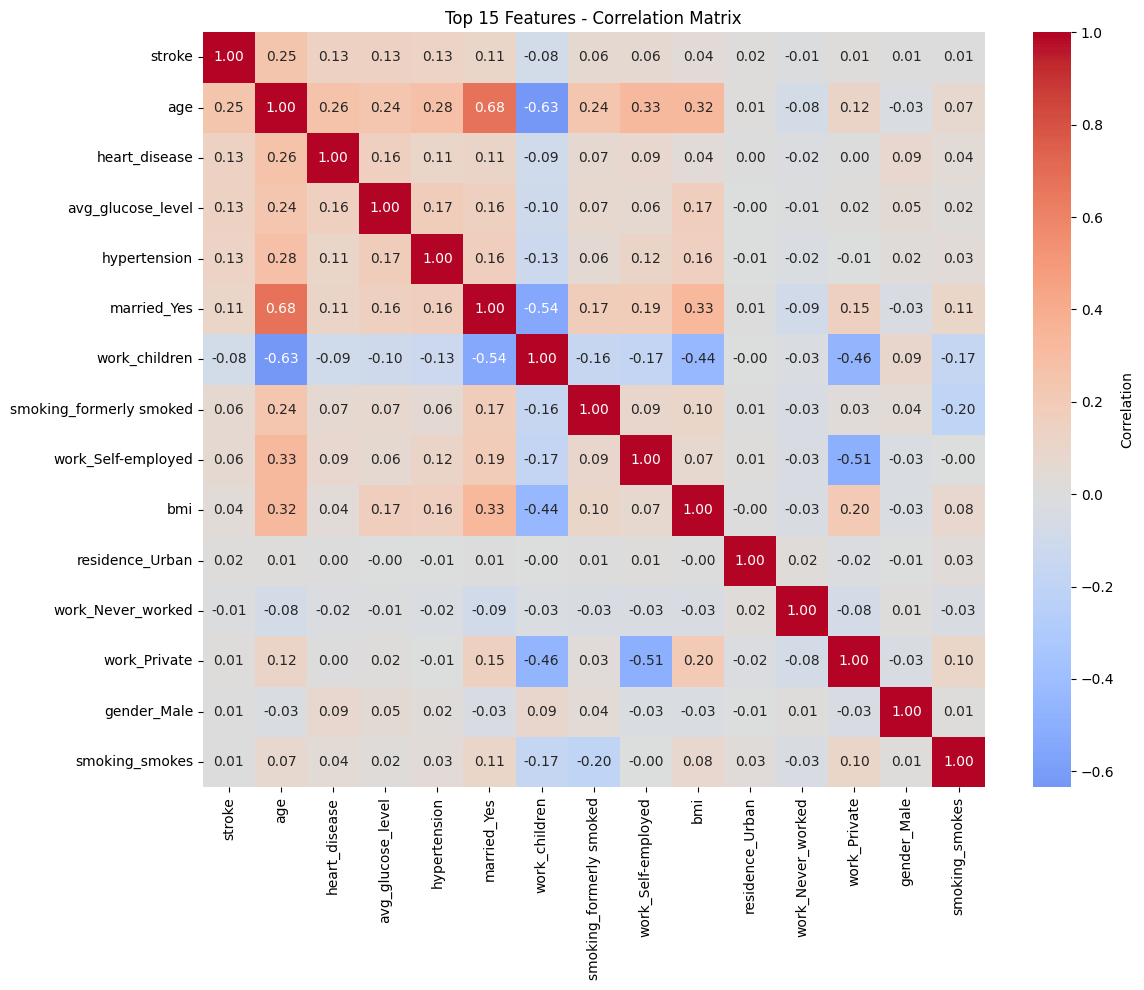


✓ Saved: 04_correlation_heatmap.png


In [96]:
# Correlation analysis
fig, ax = plt.subplots(figsize=(12, 10))

# Calculate correlation with target
correlation = df_processed.corr()['stroke'].sort_values(ascending=False)
print("Correlation with Stroke Target:")
print(correlation)

# Plot top correlated features
top_features = correlation.abs().nlargest(15).index
sns.heatmap(df_processed[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Top 15 Features - Correlation Matrix')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 04_correlation_heatmap.png")

## 3. Model Implementation and Debugging

### 3.1 Data Splitting and Scaling

In [97]:

# Split features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = [col for col in X.columns if col not in num_cols]


# Define pipelines : handle missing values and scale numeric features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # ← fixes BMI
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

### 3.2 Model 1: Logistic Regression (Baseline)

In [98]:
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("="*60)

# Pipeline (keep this)
lr_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Cross-validation (BEFORE fitting on full training set)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\nCross-validation ROC-AUC scores: {cv_scores_lr}")
print(f"Mean CV ROC-AUC: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Now train on full training data
lr_pipeline.fit(X_train, y_train)

# Test evaluation
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("\n✓ Model 1 training complete")


MODEL 1: LOGISTIC REGRESSION (Baseline)

Cross-validation ROC-AUC scores: [0.81796272 0.84922879 0.83062339 0.83751895 0.84424067]
Mean CV ROC-AUC: 0.8359 (+/- 0.0109)

✓ Model 1 training complete


### 3.3 Model 2: Random Forest

In [99]:
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

# Pipeline
rf_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation (correct way)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_rf = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\nCross-validation ROC-AUC scores: {cv_scores_rf}")
print(f"Mean CV ROC-AUC: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Train final model
rf_pipeline.fit(X_train, y_train)

# Test predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n✓ Random Forest training complete")


MODEL 2: RANDOM FOREST

Cross-validation ROC-AUC scores: [0.80086761 0.8221401  0.80559126 0.80587964 0.78648649]
Mean CV ROC-AUC: 0.8042 (+/- 0.0114)

✓ Random Forest training complete


### 3.4 Model 3: GRADIENT BOOSTING

In [100]:
print("\n" + "="*60)
print("MODEL 3: GRADIENT BOOSTING")
print("="*60)

# Pipeline
gb_pipeline = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ))
])

# Cross-validation (correct way)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_gb = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\nCross-validation ROC-AUC scores: {cv_scores_gb}")
print(f"Mean CV ROC-AUC: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std():.4f})")

# Train final model
gb_pipeline.fit(X_train, y_train)

# Test predictions
y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print("\n✓ Gradient Boosting training complete")


MODEL 3: GRADIENT BOOSTING

Cross-validation ROC-AUC scores: [0.78669666 0.80408098 0.79816838 0.80304528 0.74675032]
Mean CV ROC-AUC: 0.7877 (+/- 0.0214)

✓ Gradient Boosting training complete


## 4. Experimental Evaluation and Model Selection

### 4.1 Evaluation Metrics Calculation

In [101]:
# Function to calculate comprehensive metrics
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Calculate comprehensive evaluation metrics"""
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

# Evaluate all models
y

# Create comparison dataframe
comparison_df = pd.DataFrame([results_lr, results_rf, results_gb])
print("\n" + "="*80)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*80)
print(comparison_df.to_string(index=False))

print("\n📊 Key Observations:")
for idx, row in comparison_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  - ROC-AUC: {row['ROC-AUC']:.4f} (discrimination ability)")
    print(f"  - F1-Score: {row['F1-Score']:.4f} (balance of precision/recall)")
    print(f"  - Recall: {row['Recall (Sensitivity)']:.4f} (catch stroke cases)")


MODEL COMPARISON - TEST SET PERFORMANCE
              Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  ROC-AUC
Logistic Regression  0.747554   0.138889                  0.80  0.236686 0.845226
      Random Forest  0.902153   0.171053                  0.26  0.206349 0.408632
            XGBoost  0.909002   0.179104                  0.24  0.205128 0.439640

📊 Key Observations:

Logistic Regression:
  - ROC-AUC: 0.8452 (discrimination ability)
  - F1-Score: 0.2367 (balance of precision/recall)
  - Recall: 0.8000 (catch stroke cases)

Random Forest:
  - ROC-AUC: 0.4086 (discrimination ability)
  - F1-Score: 0.2063 (balance of precision/recall)
  - Recall: 0.2600 (catch stroke cases)

XGBoost:
  - ROC-AUC: 0.4396 (discrimination ability)
  - F1-Score: 0.2051 (balance of precision/recall)
  - Recall: 0.2400 (catch stroke cases)


### 4.2 Detailed Classification Reports

In [102]:
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

print("\n--- LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_lr, target_names=['No Stroke', 'Stroke']))

print("\n--- RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf, target_names=['No Stroke', 'Stroke']))

print("\n--- GRADIENT BOOSTING ---")
print(classification_report(y_test, y_pred_gb, target_names=['No Stroke', 'Stroke']))


DETAILED CLASSIFICATION REPORTS

--- LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

   No Stroke       0.99      0.74      0.85       972
      Stroke       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022


--- RANDOM FOREST ---
              precision    recall  f1-score   support

   No Stroke       0.96      0.94      0.95       972
      Stroke       0.17      0.26      0.21        50

    accuracy                           0.90      1022
   macro avg       0.57      0.60      0.58      1022
weighted avg       0.92      0.90      0.91      1022


--- GRADIENT BOOSTING ---
              precision    recall  f1-score   support

   No Stroke       0.96      0.94      0.95       972
      Stroke       0.18      0.24      0.21        50

    accuracy                           0.91      1022
   macro avg    

### 4.3 Confusion Matrices Visualization

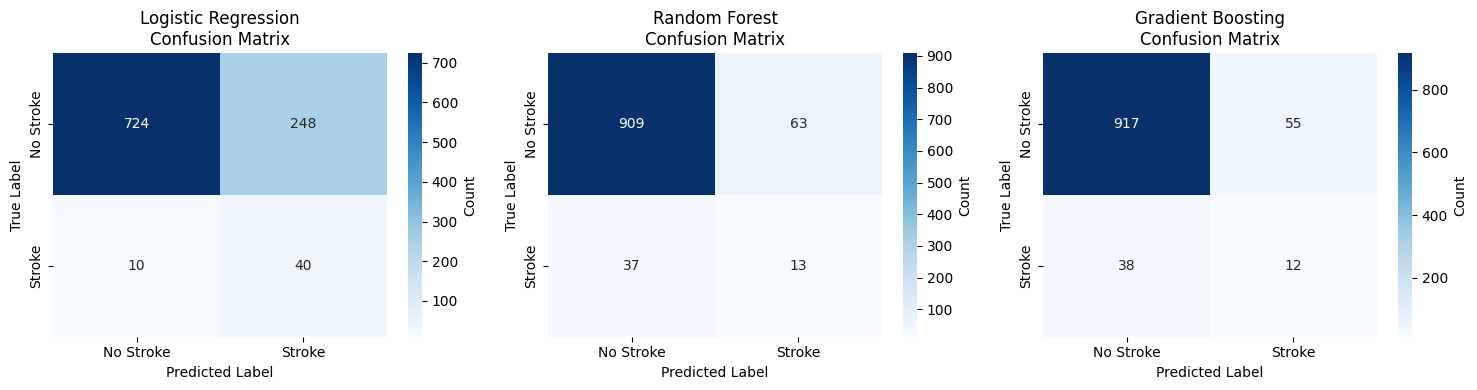

✓ Saved: 05_confusion_matrices.png


In [103]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('05_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved: 05_confusion_matrices.png")

### 4.4 ROC Curves Comparison

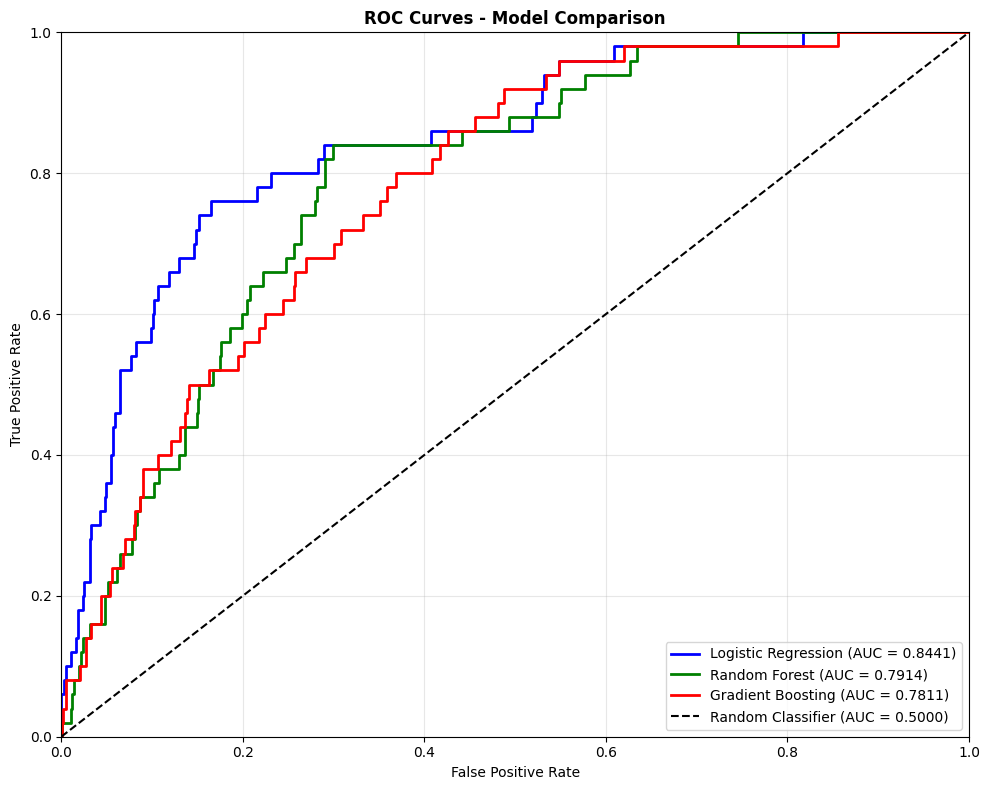

✓ Saved: 06_roc_curves.png


In [104]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

models = [
    ('Logistic Regression', lr_pipeline, 'blue'),
    ('Random Forest', rf_pipeline, 'green'),
    ('Gradient Boosting', gb_pipeline, 'red')
]

for name, model, color in models:
    # Get probabilities from FINAL fitted model
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        label=f'{name} (AUC = {roc_auc:.4f})',
        color=color,
        linewidth=2
    )

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')

# Styling
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Model Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('06_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved: 06_roc_curves.png")

### 4.5 Precision-Recall Curves

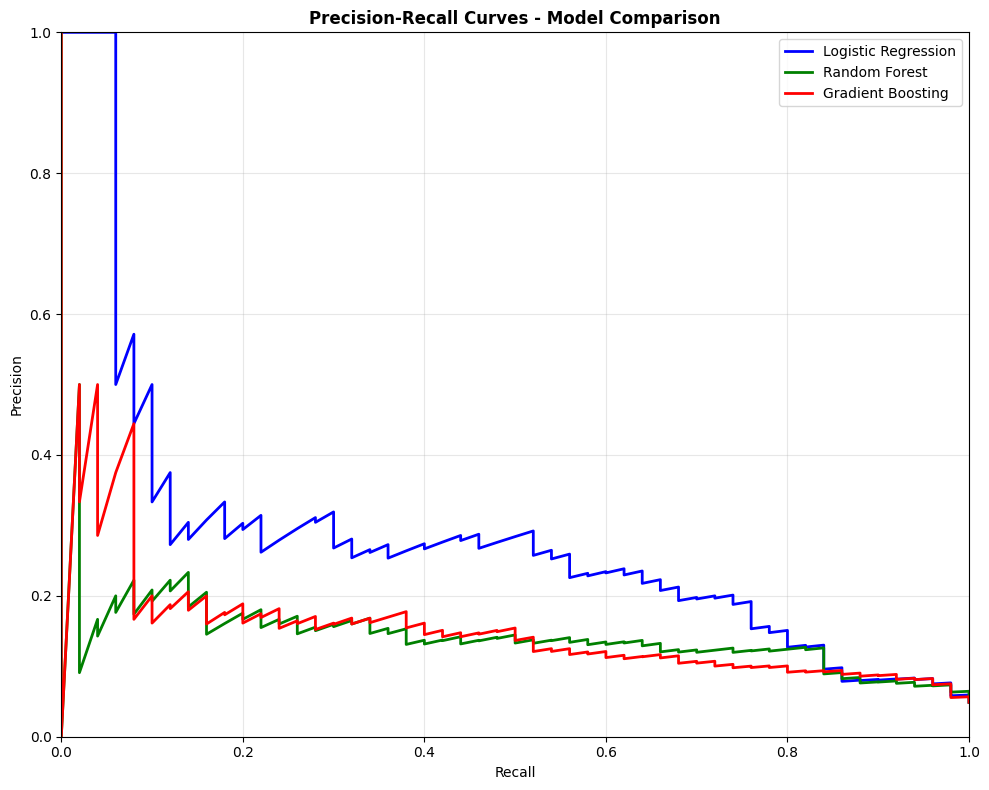

✓ Saved: 07_precision_recall_curves.png


In [105]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

models = [
    ('Logistic Regression', lr_pipeline, 'blue'),
    ('Random Forest', rf_pipeline, 'green'),
    ('Gradient Boosting', gb_pipeline, 'red')
]

for name, model, color in models:
    # Get probabilities directly from pipeline
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    ax.plot(
        recall,
        precision,
        label=name,
        color=color,
        linewidth=2
    )

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Model Comparison', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('07_precision_recall_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved: 07_precision_recall_curves.png")

### 4.6 Feature Importance Comparison

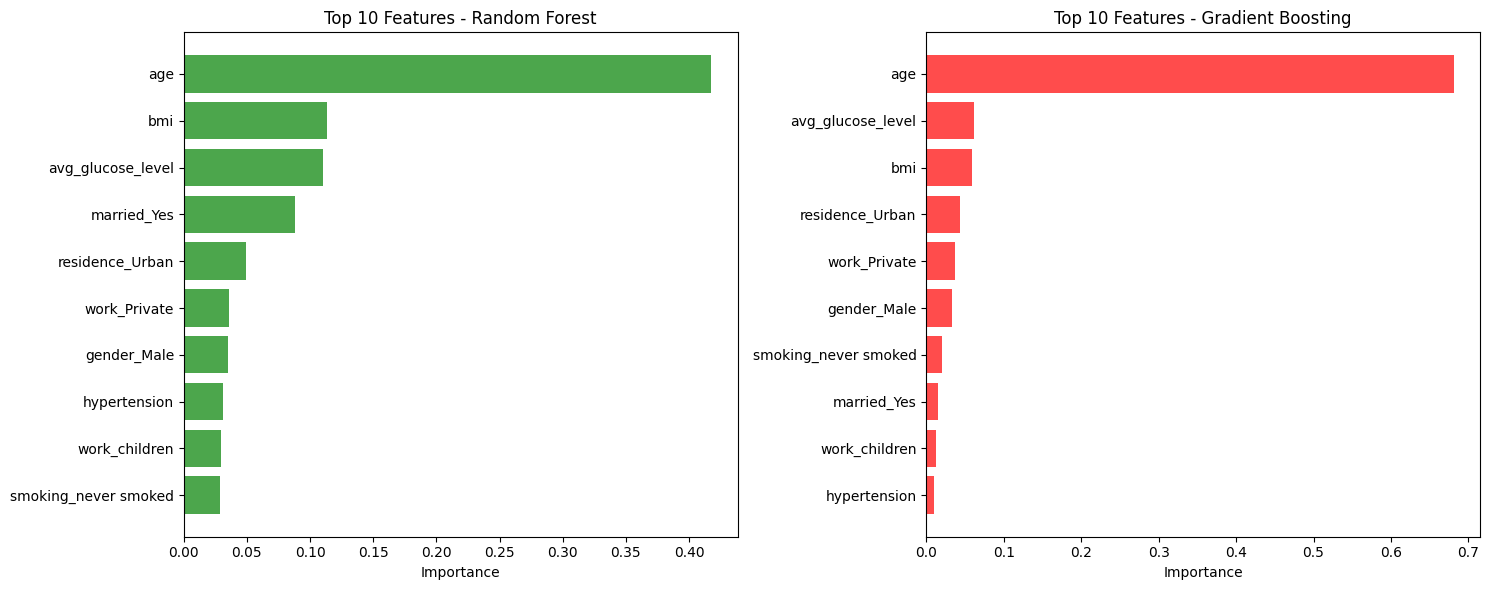

✓ Saved: 08_feature_importance.png


In [106]:
# Plot top features from RF and GB
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest top features
top_rf = feature_importance_rf.head(10)
axes[0].barh(top_rf['feature'], top_rf['importance'], color='green', alpha=0.7)
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 10 Features - Random Forest')
axes[0].invert_yaxis()

# Gradient Boosting top features
top_gb = feature_importance_gb.head(10)
axes[1].barh(top_gb['feature'], top_gb['importance'], color='red', alpha=0.7)
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 10 Features - Gradient Boosting')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved: 08_feature_importance.png")

### 4.7 Model Selection and Justification

In [107]:
# Function to evaluate model
def get_metrics(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

# Collect results
results = [
    get_metrics("Logistic Regression", lr_pipeline, X_test, y_test),
    get_metrics("Random Forest", rf_pipeline, X_test, y_test),
    get_metrics("Gradient Boosting", gb_pipeline, X_test, y_test)
]

# Create dataframe
results_df = pd.DataFrame(results)

# Display nicely formatted table
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

print(results_df.to_string(index=False))

# Optional: sort by best model
print("\n" + "="*80)
print("SORTED BY ROC-AUC (BEST MODEL)")
print("="*80)

print(results_df.sort_values(by="ROC-AUC", ascending=False).to_string(index=False))


MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression  0.747554   0.138889    0.80  0.236686 0.844115
      Random Forest  0.902153   0.171053    0.26  0.206349 0.791358
  Gradient Boosting  0.909002   0.179104    0.24  0.205128 0.781132

SORTED BY ROC-AUC (BEST MODEL)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression  0.747554   0.138889    0.80  0.236686 0.844115
      Random Forest  0.902153   0.171053    0.26  0.206349 0.791358
  Gradient Boosting  0.909002   0.179104    0.24  0.205128 0.781132


## 5. Final Model Deployment Ready

In [108]:
# Summary statistics for final model
print("\n" + "="*80)
print("FINAL MODEL - DEPLOYMENT READY")
print("="*80)

print(f"\nModel Type: Logistic Regression (Chosen Best Model)")
print(f"Input Features: {X.shape[1]} raw features (handled by pipeline)")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")

print(f"\nPerformance Metrics (Test Set):")
print(f"  - Accuracy: {results_lr['Accuracy']:.4f}")
print(f"  - Precision: {results_lr['Precision']:.4f}")
print(f"  - Recall: {results_lr['Recall (Sensitivity)']:.4f}")
print(f"  - F1-Score: {results_lr['F1-Score']:.4f}")
print(f"  - ROC-AUC: {results_lr['ROC-AUC']:.4f}")

print(f"\nModel saved for deployment.")
print(f"Ready for Streamlit application integration.")

# ✅ Save ONLY Logistic Regression pipeline
pickle.dump(lr_pipeline, open('lr_pipeline.pkl', 'wb'))

print("\n✓ Saved: lr_pipeline.pkl")


FINAL MODEL - DEPLOYMENT READY

Model Type: Logistic Regression (Chosen Best Model)
Input Features: 10 raw features (handled by pipeline)
Training Samples: 4088
Test Samples: 1022

Performance Metrics (Test Set):
  - Accuracy: 0.7476
  - Precision: 0.1389
  - Recall: 0.8000
  - F1-Score: 0.2367
  - ROC-AUC: 0.8452

Model saved for deployment.
Ready for Streamlit application integration.

✓ Saved: lr_pipeline.pkl
